<a href="https://colab.research.google.com/github/AzureDragon08/Notion-embeds/blob/main/CYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
# ===========================================================
# CROP YIELD PREDICTION USING SVM (SUPPORT VECTOR REGRESSION)
# ===========================================================
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
# Load Data
try:
    df = pd.read_csv('dataset.xls')
except Exception:
    df = pd.read_excel('dataset.xls', engine='xlrd')
print("\nDataset successfully loaded!")
print(df.head())


Dataset successfully loaded!
   Year   State  Crop  Temperature_C  Rainfall_mm  Humidity_pct  CO2_ppm  \
0  2015  Punjab  Rice          24.30        514.8          61.1    401.4   
1  2016  Punjab  Rice          24.17        601.9          60.6    400.8   
2  2017  Punjab  Rice          24.15        782.5          67.7    402.9   
3  2018  Punjab  Rice          25.00        622.5          60.5    405.3   
4  2019  Punjab  Rice          23.73        576.2          62.0    408.9   

   Area_hectares  Yield_kg_per_hectare  
0        18476.0                2602.9  
1        43371.8                2838.7  
2        59912.6                2603.2  
3        97362.8                2972.2  
4        23886.1                2669.6  


In [39]:
# ENCODING
df_encoded = pd.get_dummies(df, columns=["State", "Crop"], drop_first=True)
# Separate input features (X) and target variable (y)
X = df_encoded.drop(columns=["Yield_kg_per_hectare"])
y = df_encoded["Yield_kg_per_hectare"]

In [40]:
# Train/Test Split & Model Fitting
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
# SVM requires numbers to be on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
# TRAIN THE SVM MODEL
model = SVR(kernel="rbf", C=10000, epsilon=10)
model.fit(X_train_scaled, y_train)

SVR(C=10000, epsilon=10)

In [47]:
# Model Evaluation
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("\n--- SVM Model Performance ---")
print(f"Mean Absolute Error (MAE) : {mae:.2f} kg/ha")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} kg/ha")
print(f"R² Score                  : {r2:.4f}")


--- SVM Model Performance ---
Mean Absolute Error (MAE) : 1957.04 kg/ha
Root Mean Squared Error (RMSE): 4207.86 kg/ha
R² Score                  : 0.9698


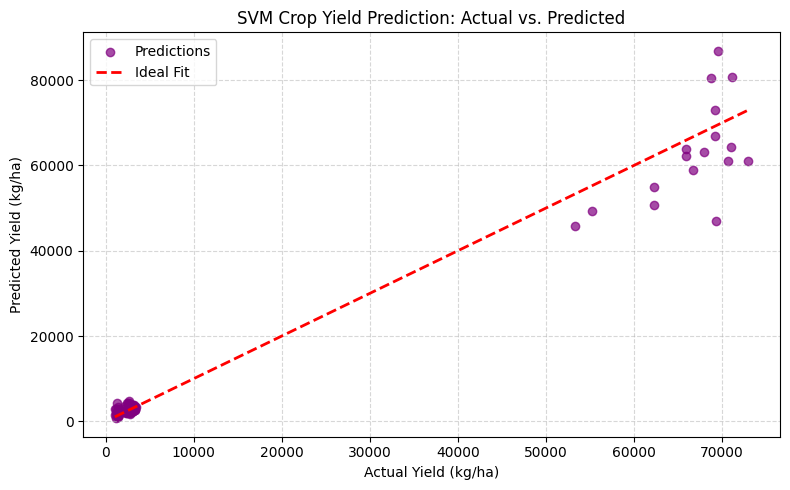

In [48]:
# Visualization
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color='purple', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal Fit')
plt.xlabel('Actual Yield (kg/ha)')
plt.ylabel('Predicted Yield (kg/ha)')
plt.title('SVM Crop Yield Prediction: Actual vs. Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [49]:
# Test
print("\n--- Running Future Climate Scenario Prediction ---")
# Define new sample inputs
future_scenario = pd.DataFrame(
    [
        {
            "Year": 2030,
            "State": "Punjab",
            "Crop": "Rice",
            "Temperature_C": 26.5,
            "Rainfall_mm": 550.0,
            "Humidity_pct": 62.0,
            "CO2_ppm": 430.0,
            "Area_hectares": 25000.0,
        },
        {
            "Year": 2030,
            "State": "Maharashtra",
            "Crop": "Sugarcane",
            "Temperature_C": 28.0,
            "Rainfall_mm": 1100.0,
            "Humidity_pct": 70.0,
            "CO2_ppm": 430.0,
            "Area_hectares": 15000.0,
        },
    ]
)
# Convert scenario text columns using same columns as training data
future_encoded = pd.get_dummies(
    future_scenario, columns=["State", "Crop"], drop_first=True
)
# Align columns to match training set (fills missing encoded columns with 0)
future_encoded = future_encoded.reindex(columns=X.columns, fill_value=0)
# Scale future inputs using the trained scaler
future_scaled = scaler.transform(future_encoded)
# Make predictions
scenario_predictions = model.predict(future_scaled)
for idx, row in future_scenario.iterrows():
    print(
        f"Scenario {idx+1} [{row['State']} - {row['Crop']} ({row['Year']})]: "
        f"Predicted Yield = {scenario_predictions[idx]:.2f} kg/ha"
    )


--- Running Future Climate Scenario Prediction ---
Scenario 1 [Punjab - Rice (2030)]: Predicted Yield = 6996.64 kg/ha
Scenario 2 [Maharashtra - Sugarcane (2030)]: Predicted Yield = 33684.08 kg/ha


In [51]:
pip install xgboost

In [54]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import xgboost as xgb

In [55]:
# Load Data
try:
    df = pd.read_csv('dataset.xls')
except Exception:
    df = pd.read_excel('dataset.xls', engine='xlrd')
print("\nDataset successfully loaded!")
print(df.head())
print("Dataset successfully loaded!")
print(df.head())


Dataset successfully loaded!
   Year   State  Crop  Temperature_C  Rainfall_mm  Humidity_pct  CO2_ppm  \
0  2015  Punjab  Rice          24.30        514.8          61.1    401.4   
1  2016  Punjab  Rice          24.17        601.9          60.6    400.8   
2  2017  Punjab  Rice          24.15        782.5          67.7    402.9   
3  2018  Punjab  Rice          25.00        622.5          60.5    405.3   
4  2019  Punjab  Rice          23.73        576.2          62.0    408.9   

   Area_hectares  Yield_kg_per_hectare  
0        18476.0                2602.9  
1        43371.8                2838.7  
2        59912.6                2603.2  
3        97362.8                2972.2  
4        23886.1                2669.6  
Dataset successfully loaded!
   Year   State  Crop  Temperature_C  Rainfall_mm  Humidity_pct  CO2_ppm  \
0  2015  Punjab  Rice          24.30        514.8          61.1    401.4   
1  2016  Punjab  Rice          24.17        601.9          60.6    400.8   
2  2017  P

In [56]:
# ENCODE TEXT COLUMNS (State & Crop) TO NUMBERS
# Converts text columns into 0s and 1s automatically
df_encoded = pd.get_dummies(df, columns=["State", "Crop"], drop_first=True)
# Separate input features (X) and target variable (y)
X = df_encoded.drop(columns=["Yield_kg_per_hectare"])  #[cite: 1, 2]
y = df_encoded["Yield_kg_per_hectare"]  #[cite: 1, 2]

In [57]:
# SPLIT DATA INTO TRAIN & TEST SETS
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
# TRAIN THE XGBOOST MODEL
print("\nTraining XGBoost Regressor Model...")
# n_estimators = number of trees to build
# learning_rate = step size for updating tree weights
model = xgb.XGBRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42
)
model.fit(X_train, y_train)


Training XGBoost Regressor Model...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [59]:
# 5. EVALUATE MODEL PERFORMANCE
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("\n--- XGBoost Model Performance ---")
print(f"Mean Absolute Error (MAE) : {mae:.2f} kg/ha")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} kg/ha")
print(f"R² Score                  : {r2:.4f}")


--- XGBoost Model Performance ---
Mean Absolute Error (MAE) : 494.48 kg/ha
Root Mean Squared Error (RMSE): 1137.98 kg/ha
R² Score                  : 0.9978


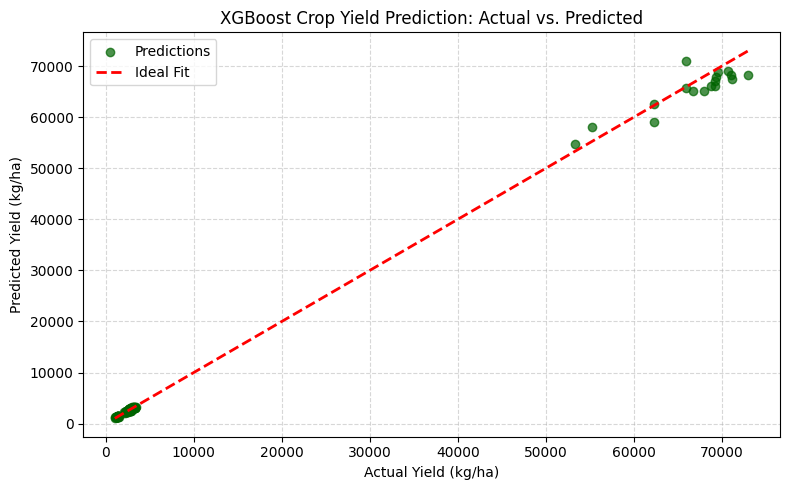

In [60]:
# 6. VISUALIZE RESULTS
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7, color="darkgreen", label="Predictions")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Ideal Fit",
)
plt.xlabel("Actual Yield (kg/ha)")
plt.ylabel("Predicted Yield (kg/ha)")
plt.title("XGBoost Crop Yield Prediction: Actual vs. Predicted")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [61]:
# 7. PREDICT FUTURE CLIMATE SCENARIOS
print("\n--- Running Future Climate Scenario Prediction ---")
# Define new sample inputs
future_scenario = pd.DataFrame(
    [
        {
            "Year": 2030,
            "State": "Punjab",
            "Crop": "Rice",
            "Temperature_C": 26.5,
            "Rainfall_mm": 550.0,
            "Humidity_pct": 62.0,
            "CO2_ppm": 430.0,
            "Area_hectares": 25000.0,
        },
        {
            "Year": 2030,
            "State": "Maharashtra",
            "Crop": "Sugarcane",
            "Temperature_C": 28.0,
            "Rainfall_mm": 1100.0,
            "Humidity_pct": 70.0,
            "CO2_ppm": 430.0,
            "Area_hectares": 15000.0,
        },
    ]
)
# Convert scenario text columns using same columns as training data
future_encoded = pd.get_dummies(
    future_scenario, columns=["State", "Crop"], drop_first=True
)
# Align columns to match training set (fills missing encoded columns with 0)
future_encoded = future_encoded.reindex(columns=X.columns, fill_value=0)
# Make predictions directly (No Scaling needed)
scenario_predictions = model.predict(future_encoded)
for idx, row in future_scenario.iterrows():
    print(
        f"Scenario {idx+1} [{row['State']} - {row['Crop']} ({row['Year']})]: "
        f"Predicted Yield = {scenario_predictions[idx]:.2f} kg/ha"
    )


--- Running Future Climate Scenario Prediction ---
Scenario 1 [Punjab - Rice (2030)]: Predicted Yield = 1430.45 kg/ha
Scenario 2 [Maharashtra - Sugarcane (2030)]: Predicted Yield = 71294.88 kg/ha
